In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

In [2]:
from sklearn import linear_model,metrics
from sklearn.model_selection import train_test_split

In [3]:
data = pd.read_csv("D:\\CODES\\Data Science\\DATA\\house_prices_inr - house_prices_inr.csv")

In [4]:
data.describe()

,Area,Price_INR
count,60.00000,6.000000e+01
mean,2225.00000,1.071367e+07
std,873.21246,6.872745e+06
min,750.00000,2.502586e+06
25%,1487.50000,5.778317e+06
50%,2225.00000,9.109538e+06
75%,2962.50000,1.409777e+07
max,3700.00000,3.938714e+07


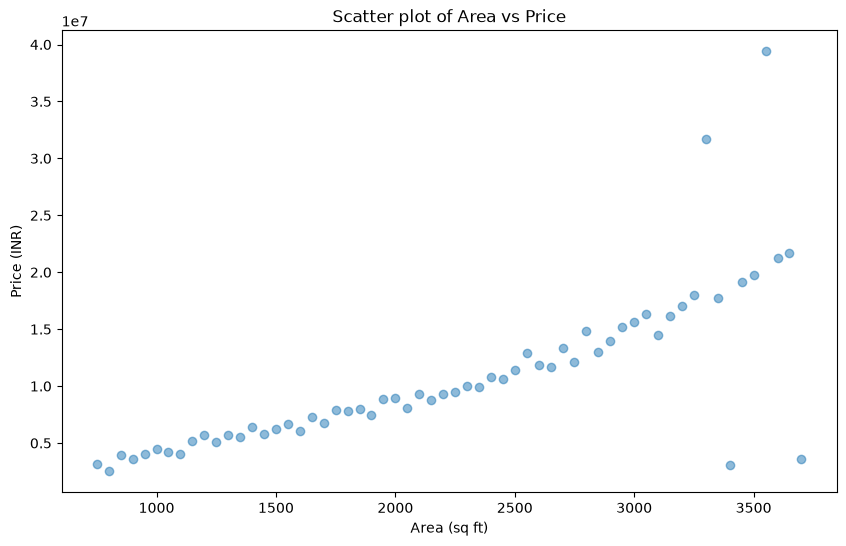

In [5]:
plt.figure(figsize=(10,6))
plt.scatter(data['Area'], data['Price_INR'], alpha=0.5)
plt.title('Scatter plot of Area vs Price')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price (INR)')
plt.show()

In [6]:
X = data[['Area']]
y = data['Price_INR']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 48 samples
Testing set size: 12 samples


In [7]:
model = LinearRegression()
model.fit(X_train, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[5910.05]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Area']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2.6e+06
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [8]:
y_pred = model.predict(X_test)
y_pred

array([ 1832400.74174528,  3309912.33691751, 12470484.22698537,
       15130005.09829539,  5673930.88919309, 17789525.96960541,
       11583977.26988203, 16016512.05539872,  5378428.57015864,
       18676032.92670875, 15425507.41732983, 16607516.69346762])

In [9]:
r2 = metrics.r2_score(y_test, y_pred)
print(f"R-squared: {r2:.4f}")

R-squared: 0.9624


In [10]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")

Mean Absolute Error: 952250.8620
Mean Squared Error: 1343124400840.1843
Root Mean Squared Error: 1158932.4402


In [11]:
min = data['Price_INR'].quantile(0.25)
max = data['Price_INR'].quantile(0.75)

print(f"Price_INR range: {min:.2f} - {max:.2f}")

Price_INR range: 5778317.25 - 14097772.00


In [12]:
area = 2000
m = model.coef_[0]
c = model.intercept_
predicted_price = m * area + c
print(f"Predicted price for area {area} sq ft: {predicted_price:.2f} INR")
print('Model Price = ', model.predict([[area]]))

Predicted price for area 2000 sq ft: 9219958.72 INR
Model Price =  [9219958.71760645]


c:\Users\Shahid Momin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
new_area =  pd.read_csv("D:\\CODES\\Data Science\\DATA\\Area.csv")
new_area.shape

(7, 1)

In [14]:
predicted_prices = model.predict(new_area)
predicted_prices_df = pd.DataFrame({'Area': new_area['Area'], 'Predicted_Price_INR': predicted_prices})

In [15]:
predicted_prices

array([2009702.13316595, 1406877.40233568, 1991971.99402388,
       2121993.01439904, 2712997.65246793, 3238991.78034925,
       3298092.24415614])

C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_21468\1366121264.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


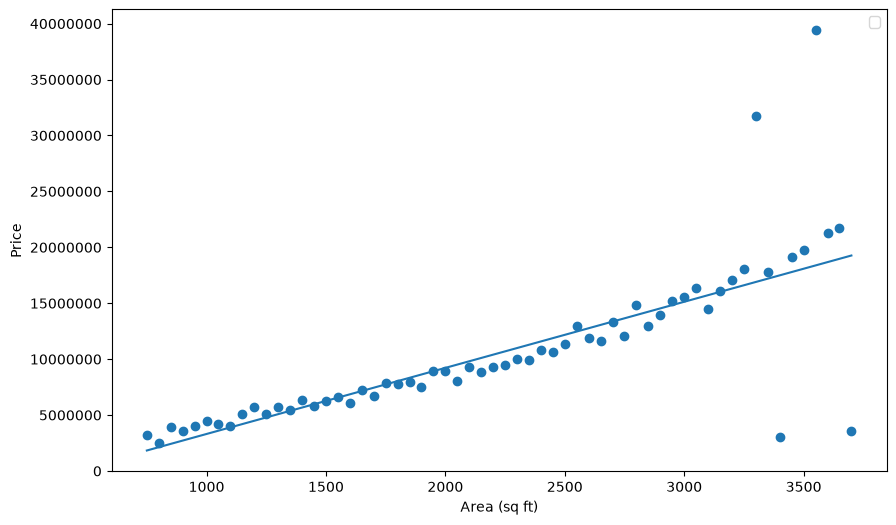

In [16]:
plt.figure(figsize=(10,6))
plt.xlabel('Area (sq ft)')
plt.ylabel('Price')
plt.scatter(data['Area'], data['Price_INR'])
plt.ticklabel_format(style='plain',axis='y')
plt.plot(data['Area'], model.predict(data[['Area']]))
plt.legend()
plt.show()

In [17]:
df = pd.read_csv("D:\\CODES\\Data Science\\DATA\\exam_scores - exam_scores.csv")
df.head()

,study_hours,exam_score
0,7.66,89.68
1,6.43,83.24
2,1.91,64.71
3,4.98,75.93
4,6.24,84.79


In [24]:
X = df[['study_hours']]
y = df['exam_score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


In [25]:
r2 = metrics.r2_score(y_test, y_pred)
r2

0.8894155080163281

C:\Users\Shahid Momin\AppData\Local\Temp\ipykernel_21468\805808657.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


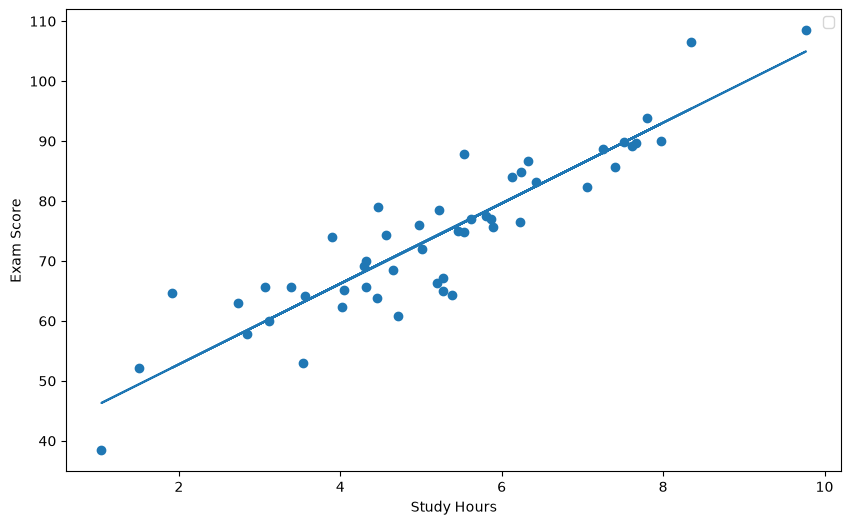

In [26]:
plt.figure(figsize=(10,6))
plt.xlabel('Study Hours')
plt.ylabel('Exam Score')
plt.scatter(X, y)
plt.ticklabel_format(style='plain',axis='y')
plt.plot(X, model.predict(X))
plt.legend()
plt.show()

In [23]:
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")


Mean Absolute Error: 7.07465108485755
Mean Squared Error: 61.55258718932295
Root Mean Squared Error: 7.84554569098434


In [27]:
r2_score = model.score(X_test, y_test)
r2_score

0.8894155080163281